In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data import load_data, regions, popls
from sklearn.impute import KNNImputer, SimpleImputer

plt.rcParams['font.family'] = 'DejaVu Sans Mono'

df = load_data()
genes = [el for el in df.columns if el.startswith('rs')]
# regions = sorted(df['region'].unique())
# popls = sorted(df['popl'].unique())

df_chs = []
for ch in 'ACGT':
    df_ch = dict()
    for gene, col in df[genes].iteritems():
        tmp = col.str.count(ch)
        tmp[col == 'NN'] = np.nan
        df_ch[f'{gene}_{ch}'] = tmp
    df_ch = pd.DataFrame(df_ch, dtype=np.float32)
    df_chs.append(df_ch)
df_chs = pd.concat(df_chs, axis=1).sort_index(axis=1)

# imputer = SimpleImputer(strategy='mean')
imputer = KNNImputer(n_neighbors=5)
X = imputer.fit_transform(df_chs)

In [66]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

ordinal_encoder = OrdinalEncoder()
Xcat = ordinal_encoder.fit_transform(df[genes].values.astype('<U2'))
one_hot_encoder = OneHotEncoder()
Xoh = one_hot_encoder.fit_transform(df[genes].values.astype('<U2'))
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['region'])

## Distance-irrelevant classifiers: CategoricalNB, Catboost

In [74]:
from sklearn.naive_bayes import CategoricalNB

X_train, X_test, y_train, y_test = train_test_split(Xcat, y, test_size=0.2, stratify=y, random_state=42)

model = CategoricalNB(
    alpha=1,
    min_categories=np.max(Xcat, axis=0).astype(int)+1
    )
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

cat_nb_fi = np.array([np.sum(np.var(np.exp( log_prob ), axis=0)) for log_prob in model.feature_log_prob_])

0.9165991902834008
0.86084142394822


In [84]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(Xoh, y, test_size=0.2, stratify=y, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

cat_dt_fi = np.empty((len(genes), ))
lb = 0
for num, cats in enumerate(one_hot_encoder.categories_):
    n_cats = len(cats)
    cat_dt_fi[num] = np.sum(model.feature_importances_[lb:lb+n_cats])
    lb += n_cats

1.0
0.8090614886731392


SpearmanrResult(correlation=0.821641332514092, pvalue=1.2230466283536377e-41)


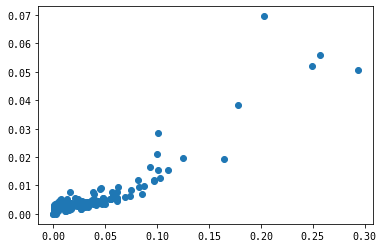

In [89]:
from scipy.stats import spearmanr
plt.scatter(cat_nb_fi, cat_dt_fi)
print(spearmanr(cat_nb_fi, cat_dt_fi))

In [22]:
from catboost import CatBoostClassifier, Pool

X_train, X_test, y_train, y_test = train_test_split(Xcat, y, test_size=0.2, stratify=y, random_state=42)
model = CatBoostClassifier()
model.fit(
    Pool(X_train, y_train, cat_features=genes, embedding_features=[], feature_names=genes),
    verbose=0
)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

accuracy on training set: 0.9822
              precision    recall  f1-score   support

           0     0.8248    0.8626    0.8433       131
           1     0.7872    0.7400    0.7629       100
           2     0.9744    0.9744    0.9744        78

    accuracy                         0.8511       309
   macro avg     0.8621    0.8590    0.8602       309
weighted avg     0.8504    0.8511    0.8504       309



## SVM

In [3]:
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

model = SVC(C=1.)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['region'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model.fit(X_train, y_train)
print( np.mean(model.predict(X_train) == y_train) )
print(np.mean(model.predict(X_test) == y_test))

0.9368421052631579
0.8576051779935275


## KNN

In [39]:
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = KNeighborsClassifier(n_neighbors=25, metric='manhattan')
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

0.8437246963562753
0.8058252427184466


c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\neighbors\_classification.py:211: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\neighbors\_classification.py:211: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, a

## Naive Bayes

In [46]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB(
    alpha=1.
)
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

0.9068825910931174
0.8705501618122977


In [6]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

0.7149797570850203
0.7119741100323624


In [7]:
from sklearn.naive_bayes import BernoulliNB

model = BernoulliNB()
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

0.9101214574898785
0.8576051779935275


In [9]:
from sklearn.naive_bayes import ComplementNB

model = ComplementNB()
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

0.6890688259109312
0.6925566343042071


## Trees

In [10]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

1.0
0.8122977346278317


In [11]:
from sklearn.tree import ExtraTreeClassifier

model = ExtraTreeClassifier()
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

1.0
0.6699029126213593


In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

1.0
0.8414239482200647


In [13]:
from sklearn.ensemble import ExtraTreesClassifier

model = ExtraTreesClassifier()
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

1.0
0.86084142394822


In [16]:
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier

model = HistGradientBoostingClassifier()
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

1.0
0.8576051779935275
